# Matching Anomalies to Astronomical Intuition

In [1]:
import os

# Set environment variables to disable multithreading
# as users will probably want to set the number of cores
# to the max of their computer.
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

In [2]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import pandas as pd


from anomaly.plot import add_line_indicators
from anomaly.plot import spec_photo_thumbnail

# from anomaly.utils import get_sdss_spec_img
from astroExplain.spectra import clustering
from autoencoders.ae import AutoEncoder
from sdss.metadata import MetaData

meta = MetaData()

# Custom functions

## Lime weights

In [3]:
def load_xai(n_segments: int, run_ids: dict, load_from: str):

    anomalies_arr = np.load(f"{load_from}/spectra_anomalies.npy", mmap_mode="r")
    specobjids_arr = np.load(f"{load_from}/specobjids_anomalies.npy", mmap_mode="r")
    weights = np.load(f"{load_from}/explanation_array_{run_id}.npy", mmap_mode="r")
    return anomalies_arr, specobjids_arr, weights

In [4]:
def load_xai_latent(run_ids_dict: dict, load_from: str):

    anomalies_arr = np.load(f"{load_from}/spectra_anomalies.npy", mmap_mode="r")
    specobjids_array = np.load(f"{load_from}/specobjids_anomalies.npy", mmap_mode="r")

    weights_dict = {}

    for n_segments in run_ids_dict.keys():

        run_id = run_ids_dict[n_segments]

        weights_dict[n_segments] = np.load(
            f"{load_from}/explanation_array_{run_id}.npy", mmap_mode="r"
        )
    return anomalies_arr, specobjids_array, weights_dict

In [5]:
def weights_prep(weights, n_segments):
    """
    Function to prepare the weights data for clustering.
    """

    data_dict = {
        "weights": weights.copy(),
        "norm_weights": None,
        "unique_weights": None,
        "norm_unique_weights": None,
    }

    data_dict["norm_weights"] = clustering.normalize_weights_l2_abs(
        data_dict["weights"]
    )

    data_dict["unique_weights"] = clustering.compress_weights_per_segments(
        weights=data_dict["weights"], n_segments=n_segments
    )

    data_dict["norm_unique_weights"] = clustering.normalize_weights_l2_abs(
        data_dict["unique_weights"]
    )

    return data_dict

In [6]:
def wave_flux_xai_to_df(wave, flux, weights, save_to, fname):
    """
    Function to save the wave, flux and xai weights to a CSV file.
    """

    # Create a DataFrame with the wave, flux and xai weights
    df = pd.DataFrame(
        {
            "wave": wave,
            "flux": flux,
            "abs_weights": weights,
        }
    )

    # Save the DataFrame to a CSV file
    df.to_csv(os.path.join(save_to, fname), index=False)
    return df

## Residuals

In [7]:
def squared_residual(spec, spec_rec):

    flux_diff = np.abs(spec - spec_rec)

    return flux_diff**2

# Config

## Constants

In [8]:
score_name_map = {
    "mse": "SE",
    "mse_filter_250": "Filter SE",
    "mse_97": "Trim SE",
    "mse_filter_250_97": "Filter + Trim SE",
    "mse_rel": "RSE",
    "mse_filter_250_rel": "Filter RSE",
    "mse_97_rel": "Trim RSE",
    "mse_filter_250_97_rel": "Filter + Trim RSE",
}

### 221 segments run ids

In [9]:
run_ids_221_dict = {
    "mse": "xai_202607061319_uniform_221_samples_50000_scale_0.9",
    "mse_filter_250": "xai_202607061811_uniform_221_samples_50000_scale_0.9",
    "mse_97": "xai_202607061937_uniform_221_samples_50000_scale_0.9",
    "mse_filter_250_97": "xai_202607062045_uniform_221_samples_50000_scale_0.9",
    # ----
    "mse_rel": "xai_202607062150_uniform_221_samples_50000_scale_0.9",
    "mse_filter_250_rel": "xai_202607070126_uniform_221_samples_50000_scale_0.9",
    "mse_97_rel": "xai_202607062313_uniform_221_samples_50000_scale_0.9",
    "mse_filter_250_97_rel": "xai_202607071050_uniform_221_samples_50000_scale_0.9",
    # ----
    'lof': 'xai_202606221052_uniform_221_samples_50000_scale_0.9',
    'iforest': 'xai_202606222135_uniform_221_samples_50000_scale_0.9',
}

### 343 segments run ids

In [10]:
run_ids_343_dict = {
    'mse': 'xai_202607141207_uniform_343_samples_50000_scale_0.9',
    'mse_filter_250': 'xai_202607141314_uniform_343_samples_50000_scale_0.9',
    'mse_97': 'xai_202607141911_uniform_343_samples_50000_scale_0.9',
    'mse_filter_250_97': 'xai_202607142055_uniform_343_samples_50000_scale_0.9',
    # ---
    'mse_rel': 'xai_202607132221_uniform_343_samples_50000_scale_0.9',
    'mse_filter_250_rel': 'xai_202607132326_uniform_343_samples_50000_scale_0.9',
    'mse_97_rel': 'xai_202607140125_uniform_343_samples_50000_scale_0.9',
    'mse_filter_250_97_rel': 'xai_202607141022_uniform_343_samples_50000_scale_0.9',
    # ----
    'lof': 'xai_202607150029_uniform_343_samples_50000_scale_0.9',
    'iforest': 'xai_202607142229_uniform_343_samples_50000_scale_0.9',
}

## Directories

In [11]:
phd_dir = "/home/elom/phd"
thesis_dir = f"{phd_dir}/thesis"
data_dir = f"{phd_dir}/code"
spectra_dir = f"{data_dir}/spectra"
scores_dir = f"{data_dir}/scores"
models_dir = f"{data_dir}/models"
latent_dir = f"{data_dir}/latent"
explanations_dir = f"{data_dir}/explanations"
ch_5_dir = f"{thesis_dir}/chapters/05_figures"

# Data

In [12]:
wave = np.load(f"{spectra_dir}/wave_spectra_imputed.npy")
wave_nm = wave * 0.1

spectra = np.load(f"{spectra_dir}/spectra_imputed.npy", mmap_mode="r")

final_meta_df = pd.read_csv(
    f"{spectra_dir}/final_spec_n_z_warning_drop.csv.gz",
    index_col="specobjid",
)

meta_with_ratios_df = pd.read_csv(
    f"{spectra_dir}/final_spec_n_z_warning_drop_with_ratios.csv.gz",
    index_col="specobjid",
)

idx_id_spec = np.load(f"{spectra_dir}/ids_imputing.npy", mmap_mode="r")
bin_id = "bin_03"
latent_arr = np.load(f"{latent_dir}/{bin_id}/latent_{bin_id}.npy", mmap_mode="r")

## VAE model

In [13]:
ae_model = AutoEncoder(
    reload=True,
    reload_from=f"{models_dir}/{bin_id}/winner",
)

## Explanations

In [14]:
bin_id = "bin_03"
n_segments = 343

if n_segments == 221:
    run_ids_dict = run_ids_221_dict
elif n_segments == 343:
    run_ids_dict = run_ids_343_dict

anomalies_all_dict = {}
specids_all_dict = {}
weights_all_dict = {}


for score_name, run_id in run_ids_dict.items():

    load_from = f"{explanations_dir}/{bin_id}/{score_name}"

    (
        anomalies_arr,
        specobjids_arr,
        weights_dict,
    ) = load_xai(n_segments=n_segments, run_ids=run_id, load_from=load_from)

    anomalies_all_dict[score_name] = anomalies_arr
    specids_all_dict[score_name] = specobjids_arr
    weights_all_dict[score_name] = weights_prep(
        weights=weights_dict, n_segments=n_segments
    )

In [15]:
weights_all_dict[score_name].keys(), weights_all_dict.keys()

(dict_keys(['weights', 'norm_weights', 'unique_weights', 'norm_unique_weights']),
 dict_keys(['mse', 'mse_filter_250', 'mse_97', 'mse_filter_250_97', 'mse_rel', 'mse_filter_250_rel', 'mse_97_rel', 'mse_filter_250_97_rel', 'lof', 'iforest']))

# Residual based anomalies sample

## Data prep

In [16]:
bin_id = "bin_03"

distinct_dict = {
    "mse": 2201231682403592192,
    "mse_filter_250": 2203468363479410688,
    "mse_97": 312016418084251648,
    "mse_filter_250_97": 2191010072388200448,
    "mse_rel": 1534667320067123200,
    "mse_filter_250_rel": 2032375840699869184,
    "mse_97_rel": 1781231151415846912,
    "mse_filter_250_97_rel": 2486018670363437056,
}

spec_distinct_dict = {}
xai_distinct_dict = {}

print("Get specs and load photometry")

save_to = f"{ch_5_dir}/{bin_id}/res_distinct_xai"

if not os.path.exists(save_to):
    os.makedirs(save_to)

for metric, objid in distinct_dict.items():

    idx_mask = specids_all_dict[metric] == objid

    _spec = anomalies_all_dict[metric][idx_mask][0]
    spec_distinct_dict[metric] = _spec

    _weights = weights_all_dict[metric]["weights"][idx_mask][0]
    _weights = np.abs(_weights) / np.nanmax(np.abs(_weights))
    xai_distinct_dict[metric] = _weights

    # # download image and spectrum
    # ra, dec = final_meta_df[['ra', 'dec']].loc[objid].values
    # get_sdss_spec_img(
    #     specobjid=objid, ra=ra, dec=dec, save_to=save_to
    # )

# Load photometry
img_distinct_dict = {}

for metric, objid in distinct_dict.items():

    img_name = f"image_{objid}.jpeg"
    img_ = mpimg.imread(f"{save_to}/{img_name}")
    img_distinct_dict[metric] = img_

Get specs and load photometry


In [17]:
final_meta_df.loc[312016418084251648]

mjd                     51908
plate                     277
fiberid                   517
run2d                      26
ra                  165.77745
dec                  0.194287
z                    0.049778
zErr                 0.000007
zWarning                    0
class                  GALAXY
subClass          STARFORMING
z_noqso                     0
zErr_noqso                  0
zWarning_noqso              0
targetType            SCIENCE
programname            legacy
instrument               SDSS
snMedian             27.02031
ABSSB             STARFORMING
BROAD             STARFORMING
ebv                  0.027564
indexArray           172263.0
Name: 312016418084251648, dtype: object

# SE

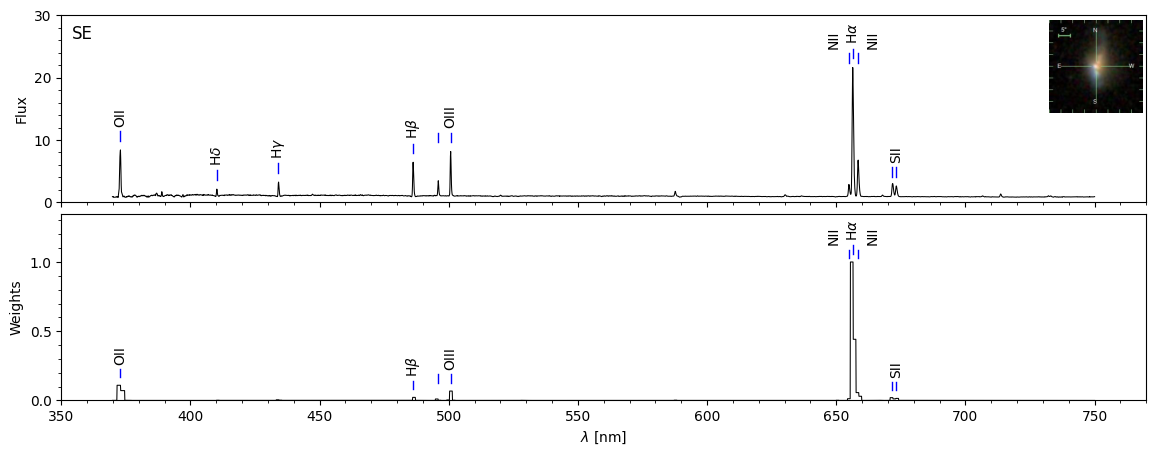

In [66]:
fig, axs = plt.subplots(2, 1, sharex=True, figsize=(14, 5))
line_width_spec = 0.75
line_width_xai = 0.75
# -------------------------------------------------------------------------------------
# 1. Panel Layout Configuration (Dictionary)
# text_x and text_y for independent positioning per panel
# -------------------------------------------------------------------------------------
panels = {
    "mse": {
        "r": 0,
        "c": 0,
        "ylim": (0, 30),
        "yticks": range(0, 31, 10),
        "bbox_to_anchor": (0.71, 0.515, 0.5, 0.5),
        "text_x": 0.01,
        "text_y": 0.9,
        "fontsize": 12,
        "ha": "left",
        "va": "center",
    },
}

# -------------------------------------------------------------------------------------
# 2. Line Indicator Configuration
# -------------------------------------------------------------------------------------
line_configs = {
    "mse": {
        "top": {
            "indicator_starts": 1.5,
            "indicator_height": 1.5,
            "delta": 1,
            "fontsize": 10,
            "active_lines": [
                "OII",
                "H_delta",
                "H_gamma",
                "H_beta",
                "OIII",
                "H_alpha",
                "SII",
            ],
        },
        "bot": {
            "indicator_starts": 0.06,
            "indicator_height": 0.06,
            "delta": 1,
            "fontsize": 10,
            "active_lines": ["OII", "H_beta", "OIII", "H_alpha", "SII"],
        },
    },
}

# -------------------------------------------------------------------------------------
# 3. Main Plotting Loop
# -------------------------------------------------------------------------------------

for metric, p_conf in panels.items():

    # Panel variables
    r, c = p_conf["r"], p_conf["c"]
    fontsize = p_conf["fontsize"]
    ylim, yticks = p_conf["ylim"], p_conf["yticks"]
    bbox_to_anchor = p_conf["bbox_to_anchor"]
    text_x, text_y = p_conf["text_x"], p_conf["text_y"]
    ha, va = p_conf["ha"], p_conf["va"]

    # Line configs for panel (default to empty dicts if none exist)
    configs = line_configs.get(metric, {})
    top_lines = configs.get("top", {})
    bot_lines = configs.get("bot", {})

    # --- Top Plot: Spec + Thumbnail ---
    axs[r], _ = spec_photo_thumbnail(
        axs[r],
        wave_nm,
        spec_distinct_dict[metric],
        img_distinct_dict[metric],
        add_image=True,
        lw=line_width_spec,
        bbox_to_anchor=bbox_to_anchor
    )
    name = score_name_map[metric]
    axs[r].set_ylim(ylim)
    axs[r].set_yticks(yticks)
    axs[r].minorticks_on()
    axs[r].text(
        text_x,
        text_y,
        f"{name}",
        ha=ha,
        va=va,
        fontsize=fontsize,
        transform=axs[r].transAxes,
    )

    if c == 0:
        axs[r].set_ylabel("Flux")

    # Add line indicators
    if top_lines.get("active_lines"):
        add_line_indicators(axs[r], wave_nm, spec_distinct_dict[metric], **top_lines)

    # --- Bottom Plot: Explanation Weights ---
    axs[r + 1], _ = spec_photo_thumbnail(
        axs[r + 1], wave_nm, xai_distinct_dict[metric], lw=line_width_xai
    )
    # abs max abs normalization of weights
    axs[r + 1].set_ylim(0, 1.35)
    axs[r + 1].set_yticks([0, 0.5, 1])
    axs[r + 1].minorticks_on()

    if c == 0:
        axs[r + 1].set_ylabel("Weights")

    # Add line indicators
    if bot_lines.get("active_lines"):
        add_line_indicators(
            axs[r + 1], wave_nm, xai_distinct_dict[metric], **bot_lines
        )

# -------------------------------------------------------------------------------------
# 4. Global Axes Settings (Bottom Row)
# -------------------------------------------------------------------------------------
wave_ticks = list(np.arange(350, 751, 50))
axs[1].set_xlim(350, 770)
axs[1].set_xticks(wave_ticks)
axs[1].set_xlabel(r"$\lambda$ [nm]")

plt.subplots_adjust(hspace=0.06, wspace=0.07)
# Save figure
fig.savefig(f"{ch_5_dir}/distinct_xai_se.pdf", bbox_inches="tight")

# Filter SE

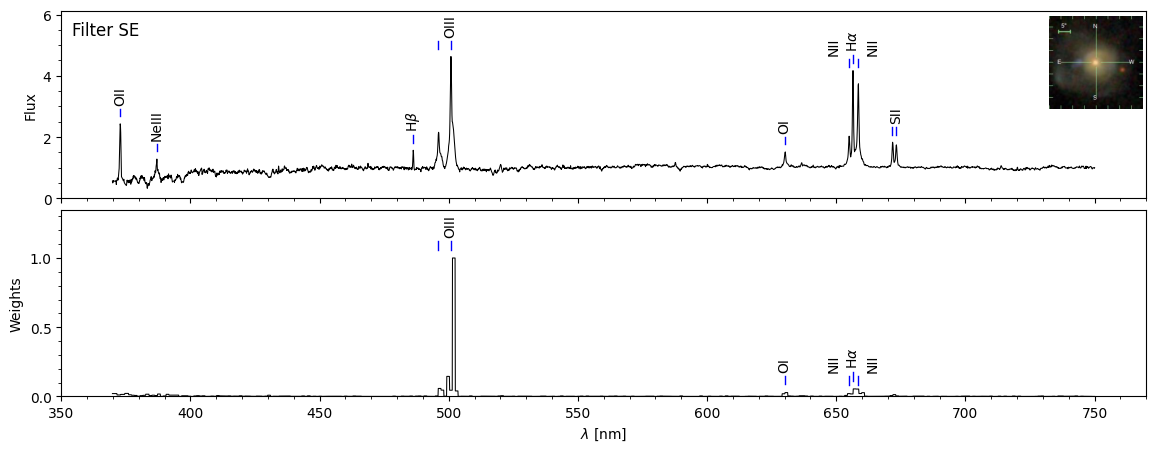

In [65]:
fig, axs = plt.subplots(2, 1, sharex=True, figsize=(14, 5))
line_width_spec = 0.75
line_width_xai = 0.75
# -------------------------------------------------------------------------------------
# 1. Panel Layout Configuration (Dictionary)
# text_x and text_y for independent positioning per panel
# -------------------------------------------------------------------------------------
panels = {
    "mse_filter_250": {
        "r": 0,
        "c": 0,
        "ylim": (0, 6.1),
        "yticks": range(0, 7, 2),
        "bbox_to_anchor": (0.71, 0.515, 0.5, 0.5),
        "text_x": 0.01,
        "text_y": 0.9,
        "fontsize": 12,
        "ha": "left",
        "va": "center",
    },
}

# -------------------------------------------------------------------------------------
# 2. Line Indicator Configuration
# -------------------------------------------------------------------------------------
line_configs = {
    "mse_filter_250": {
        "top": {
            "indicator_starts": 0.25,
            "indicator_height": 0.25,
            "delta": 2,
            "fontsize": 10,
            "active_lines": ["OII", "NeIII", "H_beta", "OIII", "OI", "H_alpha", "SII"],
        },
        "bot": {
            "indicator_starts": 0.06,
            "indicator_height": 0.06,
            "delta": 2,
            "fontsize": 10,
            "active_lines": ["OIII", "OI", "H_alpha"],
        },
    },
}

# -------------------------------------------------------------------------------------
# 3. Main Plotting Loop
# -------------------------------------------------------------------------------------

for metric, p_conf in panels.items():

    # Panel variables
    r, c = p_conf["r"], p_conf["c"]
    fontsize = p_conf["fontsize"]
    ylim, yticks = p_conf["ylim"], p_conf["yticks"]
    bbox_to_anchor = p_conf["bbox_to_anchor"]
    text_x, text_y = p_conf["text_x"], p_conf["text_y"]
    ha, va = p_conf["ha"], p_conf["va"]

    # Line configs for panel (default to empty dicts if none exist)
    configs = line_configs.get(metric, {})
    top_lines = configs.get("top", {})
    bot_lines = configs.get("bot", {})

    # --- Top Plot: Spec + Thumbnail ---
    axs[r], _ = spec_photo_thumbnail(
        axs[r],
        wave_nm,
        spec_distinct_dict[metric],
        img_distinct_dict[metric],
        add_image=True,
        lw=line_width_spec,
        bbox_to_anchor=bbox_to_anchor
    )
    name = score_name_map[metric]
    axs[r].set_ylim(ylim)
    axs[r].set_yticks(yticks)
    axs[r].minorticks_on()
    axs[r].text(
        text_x,
        text_y,
        f"{name}",
        ha=ha,
        va=va,
        fontsize=fontsize,
        transform=axs[r].transAxes,
    )

    if c == 0:
        axs[r].set_ylabel("Flux")

    # Add line indicators
    if top_lines.get("active_lines"):
        add_line_indicators(axs[r], wave_nm, spec_distinct_dict[metric], **top_lines)

    # --- Bottom Plot: Explanation Weights ---
    axs[r + 1], _ = spec_photo_thumbnail(
        axs[r + 1], wave_nm, xai_distinct_dict[metric], lw=line_width_xai
    )
    # abs max abs normalization of weights
    axs[r + 1].set_ylim(0, 1.35)
    axs[r + 1].set_yticks([0, 0.5, 1])
    axs[r + 1].minorticks_on()

    if c == 0:
        axs[r + 1].set_ylabel("Weights")

    # Add line indicators
    if bot_lines.get("active_lines"):
        add_line_indicators(
            axs[r + 1], wave_nm, xai_distinct_dict[metric], **bot_lines
        )

# -------------------------------------------------------------------------------------
# 4. Global Axes Settings (Bottom Row)
# -------------------------------------------------------------------------------------
wave_ticks = list(np.arange(350, 751, 50))
axs[1].set_xlim(350, 770)
axs[1].set_xticks(wave_ticks)
axs[1].set_xlabel(r"$\lambda$ [nm]")

plt.subplots_adjust(hspace=0.06, wspace=0.07)
# Save figure
fig.savefig(f"{ch_5_dir}/distinct_xai_se_filter.pdf", bbox_inches="tight")

# Trim SE

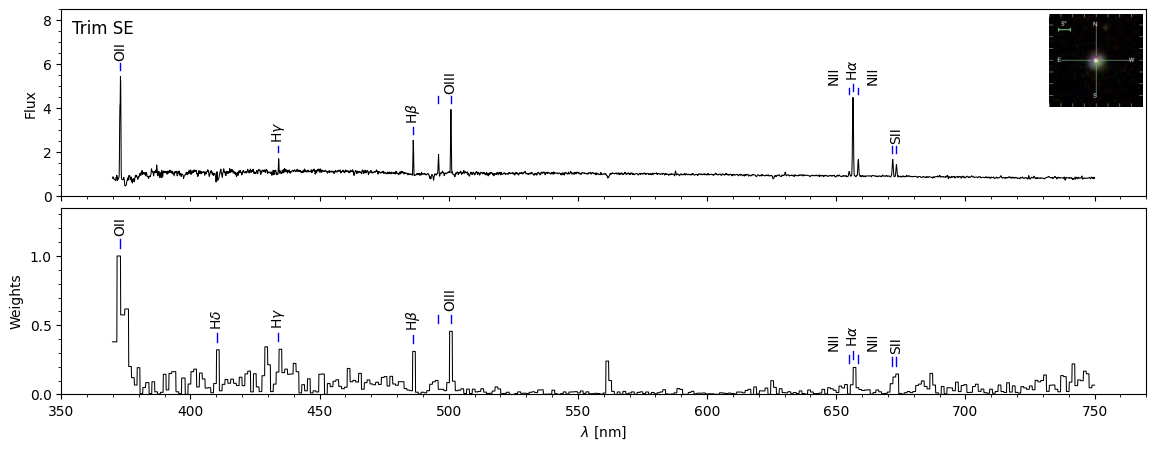

In [62]:
fig, axs = plt.subplots(2, 1, sharex=True, figsize=(14, 5))
line_width_spec = 0.75
line_width_xai = 0.75
# -------------------------------------------------------------------------------------
# 1. Panel Layout Configuration (Dictionary)
# text_x and text_y for independent positioning per panel
# -------------------------------------------------------------------------------------
panels = {
    "mse_97": {
        "r": 0,
        "c": 0,
        "ylim": (0, 8.5),
        "yticks": range(0, 9, 2),
        "bbox_to_anchor": (0.71, 0.515, 0.5, 0.5),
        "text_x": 0.01,
        "text_y": 0.9,
        "fontsize": 12,
        "ha": "left",
        "va": "center",
    },
}

# -------------------------------------------------------------------------------------
# 2. Line Indicator Configuration
# -------------------------------------------------------------------------------------
line_configs = {
    "mse_97": {
        "top": {
            "indicator_starts": 0.3,
            "indicator_height": 0.3,
            "delta": 2,
            "fontsize": 10,
            "active_lines": ["OII", "H_gamma", "H_beta", "OIII", "H_alpha", "SII"],
        },
        "bot": {
            "indicator_starts": 0.06,
            "indicator_height": 0.06,
            "delta": 2,
            "fontsize": 10,
            "active_lines": [
                "OII", "H_delta", "H_gamma", "H_beta", "OIII", "H_alpha", "SII"
            ],
        },
    },
}

# -------------------------------------------------------------------------------------
# 3. Main Plotting Loop
# -------------------------------------------------------------------------------------

for metric, p_conf in panels.items():

    # Panel variables
    r, c = p_conf["r"], p_conf["c"]
    fontsize = p_conf["fontsize"]
    ylim, yticks = p_conf["ylim"], p_conf["yticks"]
    bbox_to_anchor = p_conf["bbox_to_anchor"]
    text_x, text_y = p_conf["text_x"], p_conf["text_y"]
    ha, va = p_conf["ha"], p_conf["va"]

    # Line configs for panel (default to empty dicts if none exist)
    configs = line_configs.get(metric, {})
    top_lines = configs.get("top", {})
    bot_lines = configs.get("bot", {})

    # --- Top Plot: Spec + Thumbnail ---
    axs[r], _ = spec_photo_thumbnail(
        axs[r],
        wave_nm,
        spec_distinct_dict[metric],
        img_distinct_dict[metric],
        add_image=True,
        lw=line_width_spec,
        bbox_to_anchor=bbox_to_anchor,
    )
    name = score_name_map[metric]
    axs[r].set_ylim(ylim)
    axs[r].set_yticks(yticks)
    axs[r].minorticks_on()
    axs[r].text(
        text_x,
        text_y,
        f"{name}",
        ha=ha,
        va=va,
        fontsize=fontsize,
        transform=axs[r].transAxes,
    )

    if c == 0:
        axs[r].set_ylabel("Flux")

    # Add line indicators
    if top_lines.get("active_lines"):
        add_line_indicators(axs[r], wave_nm, spec_distinct_dict[metric], **top_lines)

    # --- Bottom Plot: Explanation Weights ---
    axs[r + 1], _ = spec_photo_thumbnail(
        axs[r + 1], wave_nm, xai_distinct_dict[metric], lw=line_width_xai
    )
    # abs max abs normalization of weights
    axs[r + 1].set_ylim(0, 1.35)
    axs[r + 1].set_yticks([0, 0.5, 1])
    axs[r + 1].minorticks_on()

    if c == 0:
        axs[r + 1].set_ylabel("Weights")

    # Add line indicators
    if bot_lines.get("active_lines"):
        add_line_indicators(
            axs[r + 1], wave_nm, xai_distinct_dict[metric], **bot_lines
        )

# -------------------------------------------------------------------------------------
# 4. Global Axes Settings (Bottom Row)
# -------------------------------------------------------------------------------------
wave_ticks = list(np.arange(350, 751, 50))
axs[1].set_xlim(350, 770)
axs[1].set_xticks(wave_ticks)
axs[1].set_xlabel(r"$\lambda$ [nm]")

plt.subplots_adjust(hspace=0.06, wspace=0.07)
# Save figure
fig.savefig(f"{ch_5_dir}/distinct_xai_trim_se.pdf", bbox_inches="tight")

## Trim SE check

Trim 3% threshold: 0.03


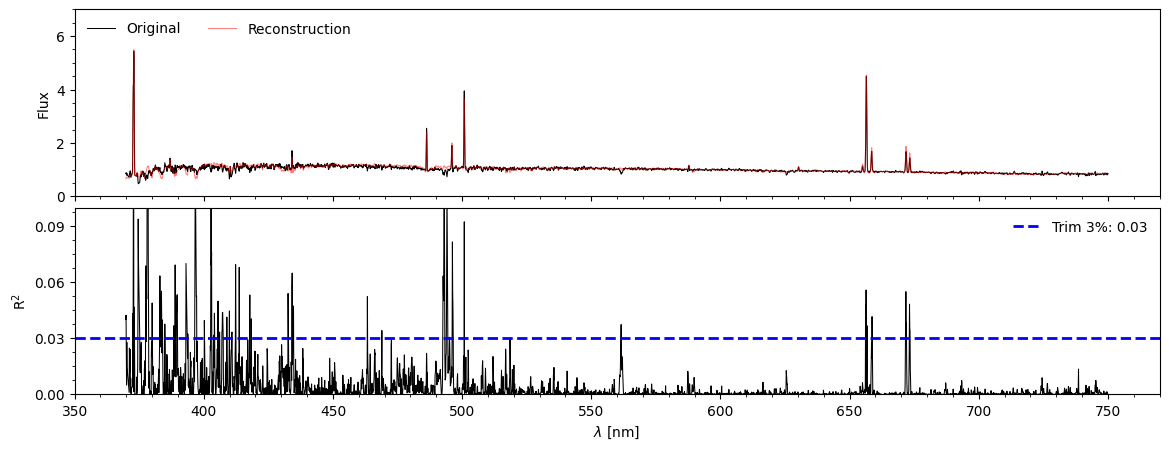

In [36]:
spec = spec_distinct_dict["mse_97"]
spec_rec = ae_model.reconstruct(spec).reshape(-1)
residual = squared_residual(spec, spec_rec)
threshold = np.nanpercentile(residual, 97)
print(f"Trim 3% threshold: {threshold:.2f}")
# ----------------------------------------------------
fig, axs = plt.subplots(2, 1, sharex=True, figsize=(14, 5))
alpha = 0.5
lw = 0.75
# ----------------------------------------------------
axs[0].plot(wave_nm, spec, color="black", label="Original", lw=lw)
axs[0].plot(wave_nm, spec_rec, alpha=alpha, color="red", label="Reconstruction", lw=lw)

flux_ticks = range(0, 7, 2)
axs[0].set_yticks(flux_ticks)
axs[0].set_ylim(0, 7)
# ----------------------------------------------------
# # Residuals
axs[1].plot(wave_nm, residual, color="black", lw=lw)
res_ticks = [0, 0.03, 0.06, 0.09]
axs[1].set_yticks(res_ticks)
axs[1].set_ylim(0, 0.1)

# ----------------------------------------------------
# threshold lines
th_label = f"Trim 3%: {threshold:.2f}"
axs[1].axhline(y=threshold, color="blue", linestyle="--", linewidth=2, label=th_label)
# ----------------------------------------------------
# labels
axs[0].legend(loc="upper left", frameon=False, ncol=2)  # fontsize=10,)
axs[1].legend(loc="upper right", frameon=False)
# ----------------------------------------------------

# wavelengt setup
axs[1].set_xlim(350, 770)
wave_ticks = list(np.arange(350, 751, 50))
axs[1].set_xticks(wave_ticks)
# set minor ticks on
for ax in axs.flatten():
    ax.minorticks_on()

# ax labels
axs[1].set_xlabel(r"$\lambda$ [nm]")
axs[0].set_ylabel("Flux")
axs[1].set_ylabel(r"R$^2$")

# adjust vertical space
plt.subplots_adjust(hspace=0.06)
# Save figure
fig.savefig(f"{ch_5_dir}/check_xai_trim_se.pdf", bbox_inches="tight")

# Filter + Trim SE

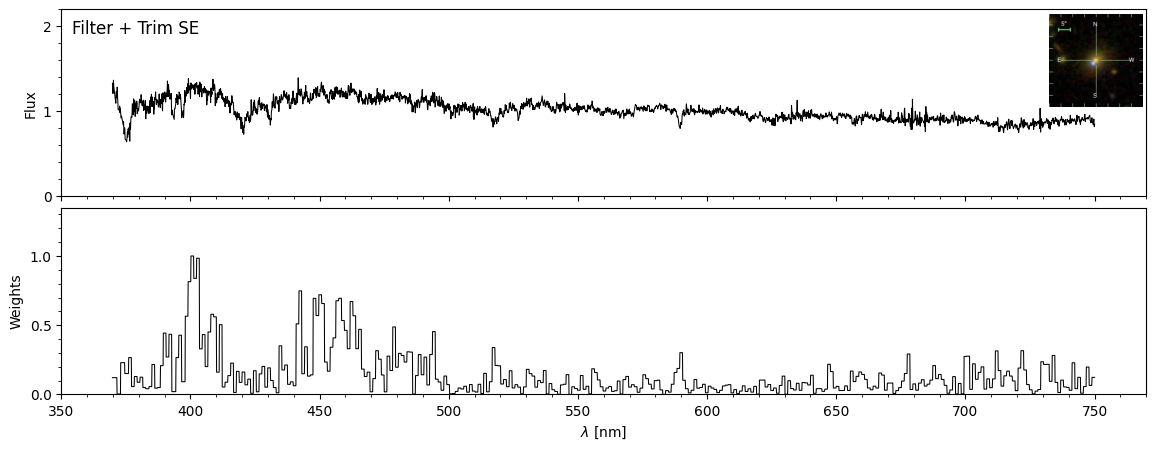

In [68]:
fig, axs = plt.subplots(2, 1, sharex=True, figsize=(14,5))
line_width_spec = 0.75
line_width_xai = 0.75
# -------------------------------------------------------------------------------------
# 1. Panel Layout Configuration (Dictionary)
# text_x and text_y for independent positioning per panel
# -------------------------------------------------------------------------------------
panels = {
    "mse_filter_250_97": {
        "r": 0,
        "c": 0,
        "ylim": (0, 2.2),
        "yticks": [0, 1, 2],
        "bbox_to_anchor": (0.71, 0.515, 0.5, 0.5),
        "text_x": 0.01,
        "text_y": 0.9,
        "fontsize": 12,
        "ha": "left",
        "va": "center",
    },
}

# -------------------------------------------------------------------------------------
# 2. Line Indicator Configuration
# -------------------------------------------------------------------------------------
line_configs = {
    "mse_filter_250_97": {
        "top": {
            "indicator_starts": 0.3,
            "indicator_height": 0.3,
            "delta": 2,
            "fontsize": 10,
            "active_lines": [],
        },
        "bot": {
            "indicator_starts": 0.06,
            "indicator_height": 0.06,
            "delta": 2,
            "fontsize": 10,
            "active_lines": [],
        },
    },
}

# -------------------------------------------------------------------------------------
# 3. Main Plotting Loop
# -------------------------------------------------------------------------------------

for metric, p_conf in panels.items():

    # Panel variables
    r, c = p_conf["r"], p_conf["c"]
    fontsize = p_conf["fontsize"]
    ylim, yticks = p_conf["ylim"], p_conf["yticks"]
    bbox_to_anchor = p_conf["bbox_to_anchor"]
    text_x, text_y = p_conf["text_x"], p_conf["text_y"]
    ha, va = p_conf["ha"], p_conf["va"]

    # Line configs for panel (default to empty dicts if none exist)
    configs = line_configs.get(metric, {})
    top_lines = configs.get("top", {})
    bot_lines = configs.get("bot", {})

    # --- Top Plot: Spec + Thumbnail ---
    axs[r], _ = spec_photo_thumbnail(
        axs[r],
        wave_nm,
        spec_distinct_dict[metric],
        img_distinct_dict[metric],
        add_image=True,
        lw=line_width_spec,
        bbox_to_anchor=bbox_to_anchor
    )
    name = score_name_map[metric]
    axs[r].set_ylim(ylim)
    axs[r].set_yticks(yticks)
    axs[r].minorticks_on()
    axs[r].text(
        text_x,
        text_y,
        f"{name}",
        ha=ha,
        va=va,
        fontsize=fontsize,
        transform=axs[r].transAxes,
    )

    if c == 0:
        axs[r].set_ylabel("Flux")

    # Add line indicators
    if top_lines.get("active_lines"):
        add_line_indicators(axs[r], wave_nm, spec_distinct_dict[metric], **top_lines)

    # --- Bottom Plot: Explanation Weights ---
    axs[r + 1], _ = spec_photo_thumbnail(
        axs[r + 1], wave_nm, xai_distinct_dict[metric], lw=line_width_xai
    )
    # abs max abs normalization of weights
    axs[r + 1].set_ylim(0, 1.35)
    axs[r + 1].set_yticks([0, 0.5, 1])
    axs[r + 1].minorticks_on()

    if c == 0:
        axs[r + 1].set_ylabel("Weights")

    # Add line indicators
    if bot_lines.get("active_lines"):
        add_line_indicators(
            axs[r + 1], wave_nm, xai_distinct_dict[metric], **bot_lines
        )

# -------------------------------------------------------------------------------------
# 4. Global Axes Settings (Bottom Row)
# -------------------------------------------------------------------------------------
wave_ticks = list(np.arange(350, 751, 50))
axs[1].set_xlim(350, 770)
axs[1].set_xticks(wave_ticks)
axs[1].set_xlabel(r"$\lambda$ [nm]")

plt.subplots_adjust(hspace=0.06, wspace=0.07)
# Save figure
fig.savefig(f"{ch_5_dir}/distinct_xai_filter_trim_se.pdf", bbox_inches="tight")

# SE and Filter SE

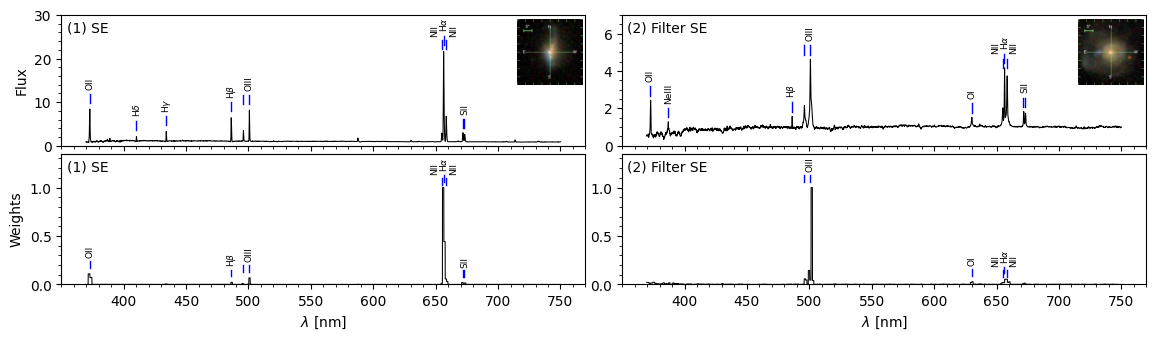

In [18]:
fig, axs = plt.subplots(2, 2, sharex=True, figsize=(14, 14/4))
line_width_spec = 0.75
line_width_xai = 0.75
# -------------------------------------------------------------------------------------
# 1. Panel Layout Configuration (Dictionary)
# text_x and text_y for independent positioning per panel
# -------------------------------------------------------------------------------------
panels = {
    "mse": {
        "prefix": "(1)",
        "r": 0,
        "c": 0,
        "ylim": (0, 30),
        "yticks": range(0, 31, 10),
        "text_x": 0.01,
        "text_y": 0.9,
        "ha": "left",
        "va": "center",
    },
    "mse_filter_250": {
        "prefix": "(2)",
        "r": 0,
        "c": 1,
        "ylim": (0, 7),
        "yticks": range(0, 7, 2),
        "text_x": 0.01,
        "text_y": 0.9,
        "ha": "left",
        "va": "center",
    },
}

# -------------------------------------------------------------------------------------
# 2. Line Indicator Configuration
# -------------------------------------------------------------------------------------
line_configs = {
    "mse": {
        "top": {
            "indicator_starts": 1.5,
            "indicator_height": 2,
            "delta": 1,
            "fontsize": 6.5,
            "active_lines": [
                "OII",
                "H_delta",
                "H_gamma",
                "H_beta",
                "OIII",
                "H_alpha",
                "SII",
            ],
        },
        "bot": {
            "indicator_starts": 0.06,
            "indicator_height": 0.07,
            "delta": 1,
            "fontsize": 6.5,
            "active_lines": ["OII", "H_beta", "OIII", "H_alpha", "SII"],
        },
    },
    "mse_filter_250": {
        "top": {
            "indicator_starts": 0.25,
            "indicator_height": 0.5,
            "delta": 2,
            "fontsize": 6.5,
            "active_lines": ["OII", "NeIII", "H_beta", "OIII", "OI", "H_alpha", "SII"],
        },
        "bot": {
            "indicator_starts": 0.06,
            "indicator_height": 0.07,
            "delta": 2,
            "fontsize": 6.5,
            "active_lines": ["OIII", "OI", "H_alpha"],
        },
    },
}

# -------------------------------------------------------------------------------------
# 3. Main Plotting Loop
# -------------------------------------------------------------------------------------

for metric, p_conf in panels.items():

    # Panel variables
    prefix, r, c = p_conf["prefix"], p_conf["r"], p_conf["c"]
    ylim, yticks = p_conf["ylim"], p_conf["yticks"]
    text_x, text_y = p_conf["text_x"], p_conf["text_y"]
    ha, va = p_conf["ha"], p_conf["va"]

    # Line configs for panel (default to empty dicts if none exist)
    configs = line_configs.get(metric, {})
    top_lines = configs.get("top", {})
    bot_lines = configs.get("bot", {})

    # --- Top Plot: Spec + Thumbnail ---
    axs[r, c], _ = spec_photo_thumbnail(
        axs[r, c],
        wave_nm,
        spec_distinct_dict[metric],
        img_distinct_dict[metric],
        add_image=True,
        lw=line_width_spec,
    )
    name = score_name_map[metric]
    axs[r, c].set_ylim(ylim)
    axs[r, c].set_yticks(yticks)
    axs[r, c].minorticks_on()
    axs[r, c].text(
        text_x,
        text_y,
        f"{prefix} {name}",
        ha=ha,
        va=va,
        transform=axs[r, c].transAxes,
    )

    if c == 0:
        axs[r, c].set_ylabel("Flux")

    # Add line indicators
    if top_lines.get("active_lines"):
        add_line_indicators(axs[r, c], wave_nm, spec_distinct_dict[metric], **top_lines)

    # --- Bottom Plot: Explanation Weights ---
    axs[r + 1, c], _ = spec_photo_thumbnail(
        axs[r + 1, c], wave_nm, xai_distinct_dict[metric], lw=line_width_xai
    )
    # abs max abs normalization of weights
    axs[r + 1, c].set_ylim(0, 1.35)
    axs[r + 1, c].set_yticks([0, 0.5, 1])
    axs[r + 1, c].minorticks_on()

    axs[r + 1, c].text(
        text_x,
        text_y,
        f"{prefix} {name}",
        ha=ha,
        va=va,
        transform=axs[r + 1, c].transAxes,
    )

    if c == 0:
        axs[r + 1, c].set_ylabel("Weights")

    # Add line indicators
    if bot_lines.get("active_lines"):
        add_line_indicators(
            axs[r + 1, c], wave_nm, xai_distinct_dict[metric], **bot_lines
        )

# -------------------------------------------------------------------------------------
# 4. Global Axes Settings (Bottom Row)
# -------------------------------------------------------------------------------------
wave_ticks = list(np.arange(400, 751, 50))
for col in [0, 1]:
    axs[1, col].set_xlim(350, 770)
    axs[1, col].set_xticks(wave_ticks)
    axs[1, col].set_xlabel(r"$\lambda$ [nm]")

plt.subplots_adjust(hspace=0.06, wspace=0.07)
# Save figure
fig.savefig(f"{ch_5_dir}/se_se_filter_distinct_xai.pdf", bbox_inches="tight")

# Trim and Filter + Trim SE

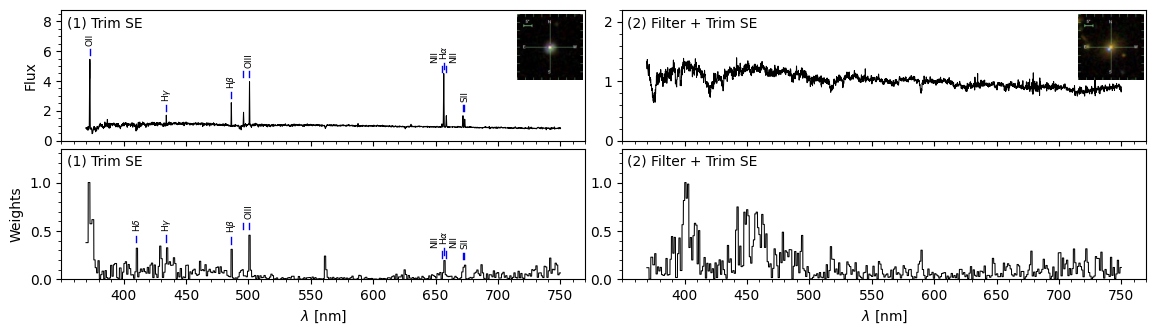

In [19]:
fig, axs = plt.subplots(2, 2, sharex=True, figsize=(14, 3.5))
line_width_spec = 0.75
line_width_xai = 0.75
# -------------------------------------------------------------------------------------
# 1. Panel Layout Configuration (Dictionary)
# text_x and text_y for independent positioning per panel
# -------------------------------------------------------------------------------------
panels = {
    "mse_97": {
        "prefix": "(1)",
        "r": 0,
        "c": 0,
        "ylim": (0, 8.75),
        "yticks": range(0, 9, 2),
        "text_x": 0.01,
        "text_y": 0.9,
        "ha": "left",
        "va": "center",
    },
    "mse_filter_250_97": {
        "prefix": "(2)",
        "r": 0,
        "c": 1,
        "ylim": (0, 2.2),
        "yticks": [0, 1, 2],
        "text_x": 0.01,
        "text_y": 0.9,
        "ha": "left",
        "va": "center",
    },
}

# -------------------------------------------------------------------------------------
# 2. Line Indicator Configuration
# -------------------------------------------------------------------------------------
line_configs = {
    "mse_97": {
        "top": {
            "indicator_starts": 0.3,
            "indicator_height": 0.4,
            "delta": 2,
            "fontsize": 6.5,
            "active_lines": [
                "OII",
                "H_gamma",
                "H_beta",
                "OIII",
                "H_alpha",
                "SII",
            ],
        },
        "bot": {
            "indicator_starts": 0.06,
            "indicator_height": 0.07,
            "delta": 2,
            "fontsize": 6.5,
            "active_lines": [
                "H_delta",
                "H_gamma",
                "H_beta",
                "OIII",
                "H_alpha",
                "SII",
            ],
        },
    },
}

# -------------------------------------------------------------------------------------
# 3. Main Plotting Loop
# -------------------------------------------------------------------------------------

for metric, p_conf in panels.items():

    # Panel variables
    prefix, r, c = p_conf["prefix"], p_conf["r"], p_conf["c"]
    ylim, yticks = p_conf["ylim"], p_conf["yticks"]
    text_x, text_y = p_conf["text_x"], p_conf["text_y"]
    ha, va = p_conf["ha"], p_conf["va"]

    # Line configs for panel (default to empty dicts if none exist)
    configs = line_configs.get(metric, {})
    top_lines = configs.get("top", {})
    bot_lines = configs.get("bot", {})

    # --- Top Plot: Spec + Thumbnail ---
    axs[r, c], _ = spec_photo_thumbnail(
        axs[r, c],
        wave_nm,
        spec_distinct_dict[metric],
        img_distinct_dict[metric],
        add_image=True,
        lw=line_width_spec,
    )
    name = score_name_map[metric]
    axs[r, c].set_ylim(ylim)
    axs[r, c].set_yticks(yticks)
    axs[r, c].minorticks_on()
    axs[r, c].text(
        text_x,
        text_y,
        f"{prefix} {name}",
        ha=ha,
        va=va,
        transform=axs[r, c].transAxes,
    )

    if c == 0:
        axs[r, c].set_ylabel("Flux")

    # Add line indicators
    if top_lines.get("active_lines"):
        add_line_indicators(axs[r, c], wave_nm, spec_distinct_dict[metric], **top_lines)

    # --- Bottom Plot: Explanation Weights ---
    axs[r + 1, c], _ = spec_photo_thumbnail(
        axs[r + 1, c], wave_nm, xai_distinct_dict[metric], lw=line_width_xai
    )
    # abs max abs normalization of weights
    axs[r + 1, c].set_ylim(0, 1.35)
    axs[r + 1, c].set_yticks([0, 0.5, 1])
    axs[r + 1, c].minorticks_on()

    axs[r + 1, c].text(
        text_x,
        text_y,
        f"{prefix} {name}",
        ha=ha,
        va=va,
        transform=axs[r + 1, c].transAxes,
    )

    if c == 0:
        axs[r + 1, c].set_ylabel("Weights")

    # Add line indicators
    if bot_lines.get("active_lines"):
        add_line_indicators(
            axs[r + 1, c], wave_nm, xai_distinct_dict[metric], **bot_lines
        )

# -------------------------------------------------------------------------------------
# 4. Global Axes Settings (Bottom Row)
# -------------------------------------------------------------------------------------
wave_ticks = list(np.arange(400, 751, 50))
for col in [0, 1]:
    axs[1, col].set_xlim(350, 770)
    axs[1, col].set_xticks(wave_ticks)
    axs[1, col].set_xlabel(r"$\lambda$ [nm]")

plt.subplots_adjust(hspace=0.06, wspace=0.07)
# Save figure
fig.savefig(f"{ch_5_dir}/se_trim_filter_distinct_xai.pdf", bbox_inches="tight")

# SE in single plot

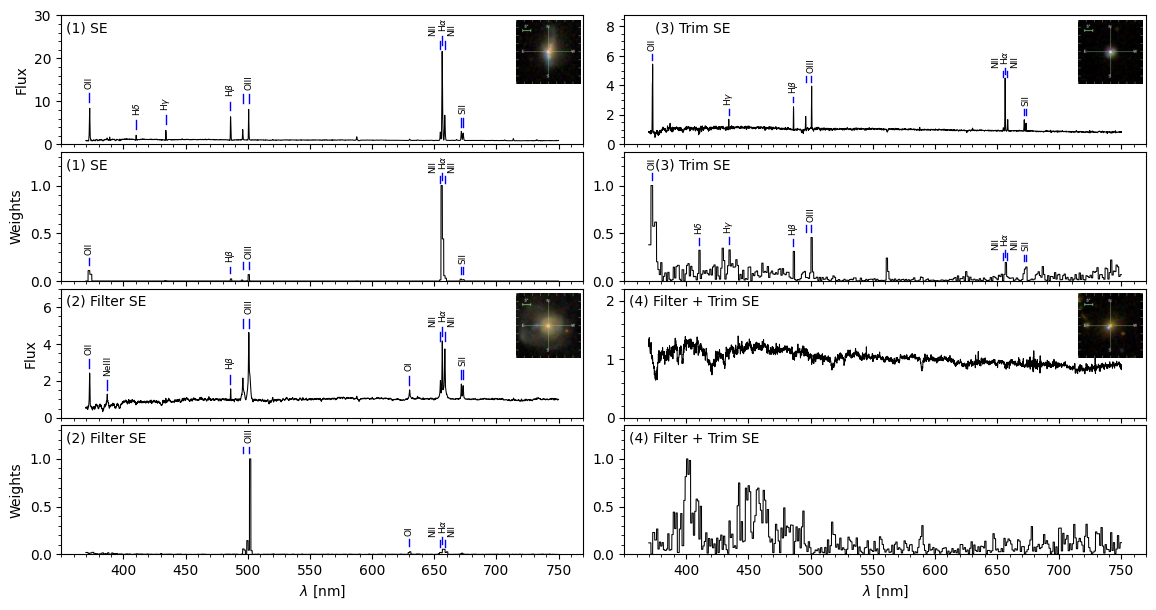

In [20]:
fig, axs = plt.subplots(4, 2, sharex=True, figsize=(14, 7))
line_width_spec = 0.75
line_width_xai = 0.75
# -------------------------------------------------------------------------------------
# 1. Panel Layout Configuration (Dictionary)
# text_x and text_y for independent positioning per panel
# -------------------------------------------------------------------------------------
panels = {
    "mse": {
        "prefix": "(1)",
        "r": 0,
        "c": 0,
        "ylim": (0, 30),
        "yticks": range(0, 31, 10),
        "text_x": 0.01,
        "text_y": 0.9,
        "ha": "left",
        "va": "center",
    },
    "mse_filter_250": {
        "prefix": "(2)",
        "r": 2,
        "c": 0,
        "ylim": (0, 7),
        "yticks": range(0, 7, 2),
        "text_x": 0.01,
        "text_y": 0.9,
        "ha": "left",
        "va": "center",
    },
    "mse_97": {
        "prefix": "(3)",
        "r": 0,
        "c": 1,
        "ylim": (0, 8.75),
        "yticks": range(0, 9, 2),
        "text_x": 0.06,
        "text_y": 0.9,
        "ha": "left",
        "va": "center",
    },
    "mse_filter_250_97": {
        "prefix": "(4)",
        "r": 2,
        "c": 1,
        "ylim": (0, 2.2),
        "yticks": [0, 1, 2],
        "text_x": 0.01,
        "text_y": 0.9,
        "ha": "left",
        "va": "center",
    },
}

# -------------------------------------------------------------------------------------
# 2. Line Indicator Configuration
# -------------------------------------------------------------------------------------
line_configs = {
    "mse": {
        "top": {
            "indicator_starts": 1.5,
            "indicator_height": 2,
            "delta": 1,
            "fontsize": 6.5,
            "active_lines": [
                "OII",
                "H_delta",
                "H_gamma",
                "H_beta",
                "OIII",
                "H_alpha",
                "SII",
            ],
        },
        "bot": {
            "indicator_starts": 0.06,
            "indicator_height": 0.07,
            "delta": 1,
            "fontsize": 6.5,
            "active_lines": ["OII", "H_beta", "OIII", "H_alpha", "SII"],
        },
    },
    "mse_filter_250": {
        "top": {
            "indicator_starts": 0.25,
            "indicator_height": 0.5,
            "delta": 2,
            "fontsize": 6.5,
            "active_lines": ["OII", "NeIII", "H_beta", "OIII", "OI", "H_alpha", "SII"],
        },
        "bot": {
            "indicator_starts": 0.06,
            "indicator_height": 0.07,
            "delta": 2,
            "fontsize": 6.5,
            "active_lines": ["OIII", "OI", "H_alpha"],
        },
    },
    "mse_97": {
        "top": {
            "indicator_starts": 0.3,
            "indicator_height": 0.4,
            "delta": 2,
            "fontsize": 6.5,
            "active_lines": [
                "OII",
                "H_gamma",
                "H_beta",
                "OIII",
                "H_alpha",
                "SII",
            ],
        },
        "bot": {
            "indicator_starts": 0.06,
            "indicator_height": 0.07,
            "delta": 2,
            "fontsize": 6.5,
            "active_lines": [
                "OII",
                "H_delta",
                "H_gamma",
                "H_beta",
                "OIII",
                "H_alpha",
                "SII",
            ],
        },
    },
}

# -------------------------------------------------------------------------------------
# 3. Main Plotting Loop
# -------------------------------------------------------------------------------------

for metric, p_conf in panels.items():

    # save to csv
    _ = wave_flux_xai_to_df(
        wave=wave_nm,
        flux=spec_distinct_dict[metric],
        weights=xai_distinct_dict[metric],
        save_to=save_to,
        fname=f"{ch_5_dir}/{metric}_distinct_xai.csv",
    )

    # Panel variables
    prefix, r, c = p_conf["prefix"], p_conf["r"], p_conf["c"]
    ylim, yticks = p_conf["ylim"], p_conf["yticks"]
    text_x, text_y = p_conf["text_x"], p_conf["text_y"]
    ha, va = p_conf["ha"], p_conf["va"]

    # Line configs for panel (default to empty dicts if none exist)
    configs = line_configs.get(metric, {})
    top_lines = configs.get("top", {})
    bot_lines = configs.get("bot", {})

    # --- Top Plot: Spec + Thumbnail ---
    axs[r, c], _ = spec_photo_thumbnail(
        axs[r, c],
        wave_nm,
        spec_distinct_dict[metric],
        img_distinct_dict[metric],
        add_image=True,
        lw=line_width_spec,
    )
    name = score_name_map[metric]
    axs[r, c].set_ylim(ylim)
    axs[r, c].set_yticks(yticks)
    axs[r, c].minorticks_on()
    axs[r, c].text(
        text_x,
        text_y,
        f"{prefix} {name}",
        ha=ha,
        va=va,
        transform=axs[r, c].transAxes,
    )

    if c == 0:
        axs[r, c].set_ylabel("Flux")

    # Add line indicators
    if top_lines.get("active_lines"):
        add_line_indicators(axs[r, c], wave_nm, spec_distinct_dict[metric], **top_lines)

    # --- Bottom Plot: Explanation Weights ---
    axs[r + 1, c], _ = spec_photo_thumbnail(
        axs[r + 1, c], wave_nm, xai_distinct_dict[metric], lw=line_width_xai
    )
    # abs max abs normalization of weights
    axs[r + 1, c].set_ylim(0, 1.35)
    axs[r + 1, c].set_yticks([0, 0.5, 1])
    axs[r + 1, c].minorticks_on()

    # # # with signs max abs normalization of weights
    # axs[r + 1, c].set_ylim(-1.35, 1.35)
    # axs[r + 1, c].set_yticks([-1, -0.5, 0, 0.5, 1])
    # axs[r + 1, c].minorticks_on()

    axs[r + 1, c].text(
        text_x,
        text_y,
        f"{prefix} {name}",
        ha=ha,
        va=va,
        transform=axs[r + 1, c].transAxes,
    )

    if c == 0:
        axs[r + 1, c].set_ylabel("Weights")

    # Add line indicators
    if bot_lines.get("active_lines"):
        add_line_indicators(
            axs[r + 1, c], wave_nm, xai_distinct_dict[metric], **bot_lines
        )

# -------------------------------------------------------------------------------------
# 4. Global Axes Settings (Bottom Row)
# -------------------------------------------------------------------------------------
wave_ticks = list(np.arange(400, 751, 50))
for col in [0, 1]:
    axs[3, col].set_xlim(350, 770)
    axs[3, col].set_xticks(wave_ticks)
    axs[3, col].set_xlabel(r"$\lambda$ [nm]")

plt.subplots_adjust(hspace=0.06, wspace=0.078)
# Save figure
# fig.savefig(f"{ch_5_dir}/se_distinct_xai.pdf", bbox_inches="tight")

# RSE in single plot

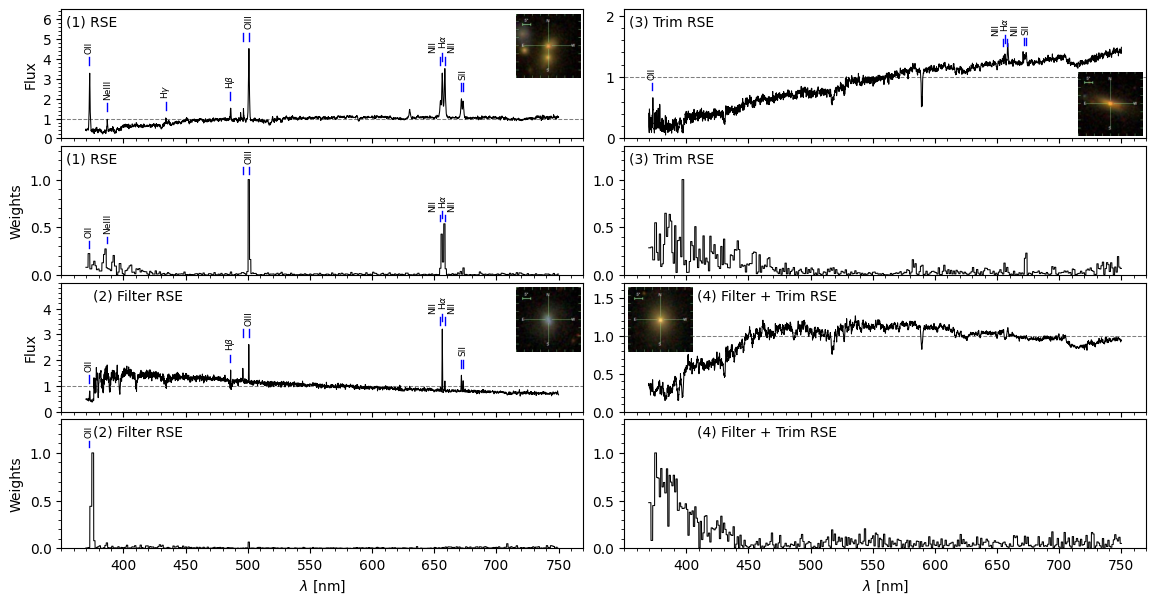

In [22]:
fig, axs = plt.subplots(4, 2, sharex=True, figsize=(14, 7))
line_width_spec = 0.75
line_width_xai = 0.75
# -------------------------------------------------------------------------------------
# 1. Panel Layout Configuration (Dictionary)
# Added text_x and text_y for independent positioning per panel
# -------------------------------------------------------------------------------------
panels = {
    "mse_rel": {
        "prefix": "(1)",
        "r": 0,
        "c": 0,
        "ylim": (0, 6.5),
        "yticks": range(0, 7, 1),
        "bbox_to_anchor": (0.695, 0.52, 0.5, 0.5),
        "text_x": 0.01,
        "text_y": 0.9,
        "ha": "left",
        "va": "center",
    },
    "mse_filter_250_rel": {
        "prefix": "(2)",
        "r": 2,
        "c": 0,
        "ylim": (0, 5),
        "yticks": range(0, 5, 1),
        "bbox_to_anchor": (0.695, 0.52, 0.5, 0.5),
        "text_x": 0.06,
        "text_y": 0.9,
        "ha": "left",
        "va": "center",
    },
    "mse_97_rel": {
        "prefix": "(3)",
        "r": 0,
        "c": 1,
        "ylim": (0, 2.1),
        "yticks": range(0, 3, 1),
        "bbox_to_anchor": (0.695, 0.07, 0.5, 0.5),
        "text_x": 0.01,
        "text_y": 0.9,
        "ha": "left",
        "va": "center",
    },
    "mse_filter_250_97_rel": {
        "prefix": "(4)",
        "r": 2,
        "c": 1,
        "ylim": (0, 1.7),
        "yticks": [0, 0.5, 1, 1.5],
        "bbox_to_anchor": (-0.167, 0.52, 0.5, 0.5),
        "text_x": 0.14,
        "text_y": 0.9,
        "ha": "left",
        "va": "center",
    },
}

# -------------------------------------------------------------------------------------
# 2. Line Indicator Configuration
# -------------------------------------------------------------------------------------
line_configs = {
    "mse_rel": {
        "top": {
            "indicator_starts": 0.4,
            "indicator_height": 0.4,
            "delta": 10,
            "fontsize": 6.5,
            "active_lines": [
                "OII",
                "NeIII",
                "H_gamma",
                "H_beta",
                "OIII",
                "H_alpha",
                "SII",
            ],
        },
        "bot": {
            "indicator_starts": 0.06,
            "indicator_height": 0.07,
            "delta": 6,
            "fontsize": 6.5,
            "active_lines": ["OII", "NeIII", "OIII", "H_alpha"],
        },
    },
    "mse_filter_250_rel": {
        "top": {
            "indicator_starts": 0.3,
            "indicator_height": 0.3,
            "delta": 2,
            "fontsize": 6.5,
            "active_lines": ["OII", "H_beta", "OIII", "H_alpha", "SII"],
        },
        "bot": {
            "indicator_starts": 0.06,
            "indicator_height": 0.07,
            "delta": 2,
            "fontsize": 6.5,
            "active_lines": ["OII"],
        },
    },
    "mse_97_rel": {
        "top": {
            "indicator_starts": 0.12,
            "indicator_height": 0.12,
            "delta": 2,
            "fontsize": 6.5,
            "active_lines": ["OII", "H_alpha", "SII"],
        },
    },
}

# -------------------------------------------------------------------------------------
# 3. Main Plotting Loop
# -------------------------------------------------------------------------------------

for metric, p_conf in panels.items():

    # Panel variables
    prefix, r, c = p_conf["prefix"], p_conf["r"], p_conf["c"]
    ylim, yticks = p_conf["ylim"], p_conf["yticks"]
    bbox_to_anchor = p_conf["bbox_to_anchor"]
    text_x, text_y = p_conf["text_x"], p_conf["text_y"]
    ha, va = p_conf["ha"], p_conf["va"]

    # Line configs for panel (default to empty dicts if none exist)
    configs = line_configs.get(metric, {})
    top_lines = configs.get("top", {})
    bot_lines = configs.get("bot", {})

    # --- Top Plot: Spec + Thumbnail ---
    axs[r, c], _ = spec_photo_thumbnail(
        axs[r, c],
        wave_nm,
        spec_distinct_dict[metric],
        img_distinct_dict[metric],
        add_image=True,
        bbox_to_anchor=bbox_to_anchor,
        lw=line_width_spec,
    )
    axs[r, c].set_ylim(ylim)
    axs[r, c].set_yticks(yticks)
    axs[r, c].minorticks_on()
    axs[r, c].axhline(
        y=1, color="black", linestyle="--", linewidth=0.75, zorder=5, alpha=0.5
    )
    name = score_name_map[metric]
    axs[r, c].text(
        text_x,
        text_y,
        f"{prefix} {name}",
        ha=ha,
        va=va,
        transform=axs[r, c].transAxes,
    )

    if c == 0:
        axs[r, c].set_ylabel("Flux")

    # Add line indicators
    if top_lines.get("active_lines"):
        add_line_indicators(axs[r, c], wave_nm, spec_distinct_dict[metric], **top_lines)

    # --- Bottom Plot: Explanation Weights ---
    axs[r + 1, c], _ = spec_photo_thumbnail(
        axs[r + 1, c], wave_nm, xai_distinct_dict[metric], lw=line_width_xai
    )
    axs[r + 1, c].set_ylim(0, 1.35)
    axs[r + 1, c].set_yticks([0, 0.5, 1])
    axs[r + 1, c].minorticks_on()
    axs[r + 1, c].text(
        text_x,
        text_y,
        f"{prefix} {name}",
        ha=ha,
        va=va,
        transform=axs[r + 1, c].transAxes,
    )

    if c == 0:
        axs[r + 1, c].set_ylabel("Weights")

    # Add line indicators
    if bot_lines.get("active_lines"):
        add_line_indicators(
            axs[r + 1, c], wave_nm, xai_distinct_dict[metric], **bot_lines
        )

# -------------------------------------------------------------------------------------
# 4. Global Axes Settings (Bottom Row)
# -------------------------------------------------------------------------------------
wave_ticks = list(np.arange(400, 751, 50))
for col in [0, 1]:
    axs[3, col].set_xlim(350, 770)
    axs[3, col].set_xticks(wave_ticks)
    axs[3, col].set_xlabel(r"$\lambda$ [nm]")

plt.subplots_adjust(hspace=0.06, wspace=0.078)
# Save figure
fig.savefig(f"{ch_5_dir}/rse_distinct_xai.pdf", bbox_inches="tight")

# iForest Explanations

## Data prep

In [23]:
bin_id = "bin_03"
iforest_specobjids_array = specids_all_dict['iforest']
iforest_anomalies_arr = anomalies_all_dict['iforest']
weights_iforest_dict = weights_all_dict['iforest']

iforest_dict = {
    "oiii_mgrt_h_alpha": 1928785351883646976,
    "oiii_sim_h_alpha_no_oii": 749873288389355520,
    "oiii_sim_h_alpha": 2390364730700097536,
    "h_alpha_grt_oiii": 694769887481980928,
}

spec_iforest_dict = {}
xai_iforest_dict = {}

print("Get specs and load photometry")

save_to = f"{ch_5_dir}/{bin_id}/latent_xai/iforest"

if not os.path.exists(save_to):
    os.makedirs(save_to)

for key, objid in iforest_dict.items():

    idx_mask = iforest_specobjids_array == objid
    spec_iforest_dict[key] = iforest_anomalies_arr[idx_mask][0]

    _weights = weights_iforest_dict['weights'][idx_mask][0]
    _weights = np.abs(_weights) / np.nanmax(np.abs(_weights))
    xai_iforest_dict[key] = _weights

    # # download image and spectrum
    # ra, dec = final_meta_df[["ra", "dec"]].loc[objid].values
    # get_sdss_spec_img(specobjid=objid, ra=ra, dec=dec, save_to=save_to)

# Load photometry
img_iforest_dict = {}

for key in iforest_dict.keys():

    objid = iforest_dict[key]
    img_name = f"image_{objid}.jpeg"
    img_ = mpimg.imread(f"{save_to}/{img_name}")
    img_iforest_dict[key] = img_

Get specs and load photometry


## Figure

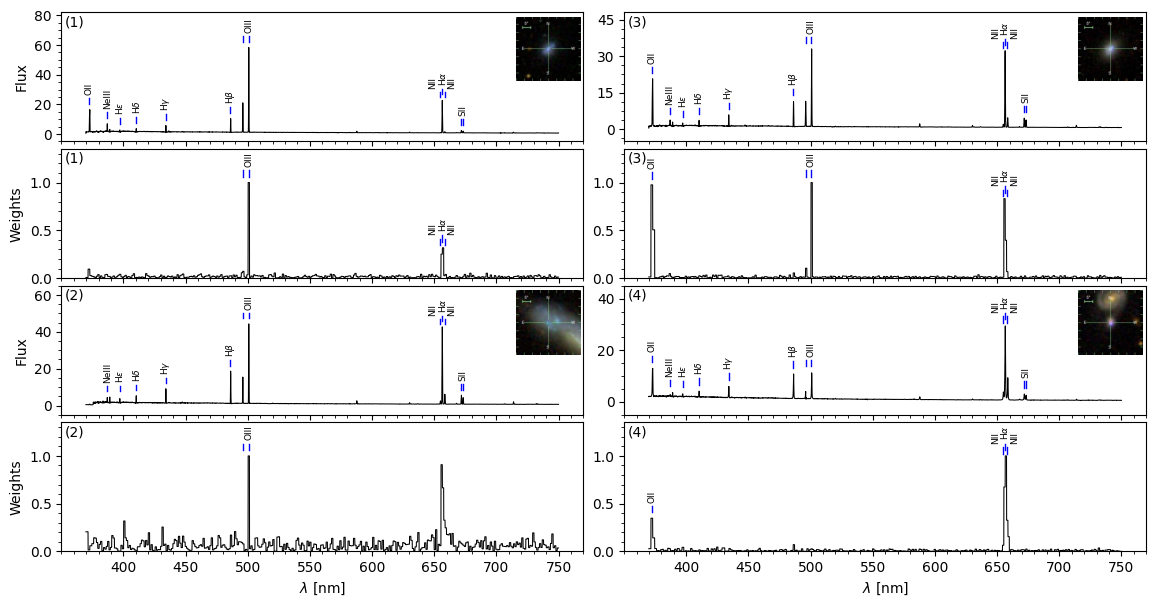

In [25]:
fig, axs = plt.subplots(4, 2, sharex=True, figsize=(14, 7))
line_width_spec = 0.75
line_width_xai = 0.75
# -------------------------------------------------------------------------------------
# 1. Panel Layout Configuration (Dictionary)
# Added text_x and text_y for independent positioning per panel
# -------------------------------------------------------------------------------------
panels = {
    "oiii_mgrt_h_alpha": {
        "prefix": "(1)",
        "r": 0,
        "c": 0,
        "ylim": (-5, 82),
        "yticks": range(0, 85, 20),
        "bbox_to_anchor": (0.695, 0.52, 0.5, 0.5),
        "text_x": 0.0075,
        "text_y": 0.925,
        "ha": "left",
        "va": "center",
    },
    "oiii_sim_h_alpha_no_oii": {
        "prefix": "(2)",
        "r": 2,
        "c": 0,
        "ylim": (-5, 65),
        "yticks": range(0, 61, 20),
        "bbox_to_anchor": (0.695, 0.52, 0.5, 0.5),
        "text_x": 0.0075,
        "text_y": 0.925,
        "ha": "left",
        "va": "center",
    },
    "oiii_sim_h_alpha": {
        "prefix": "(3)",
        "r": 0,
        "c": 1,
        "ylim": (-5, 48),
        "yticks": range(0, 46, 15),
        "bbox_to_anchor": (0.695, 0.52, 0.5, 0.5),
        "text_x": 0.0075,
        "text_y": 0.925,
        "ha": "left",
        "va": "center",
    },
    "h_alpha_grt_oiii": {
        "prefix": "(4)",
        "r": 2,
        "c": 1,
        "ylim": (-5, 45),
        "yticks": range(0, 41, 20),
        "bbox_to_anchor": (0.695, 0.52, 0.5, 0.5),
        "text_x": 0.0075,
        "text_y": 0.925,
        "ha": "left",
        "va": "center",
    },
}

# -------------------------------------------------------------------------------------
# 2. Line Indicator Configuration
# -------------------------------------------------------------------------------------
line_configs = {
    "oiii_mgrt_h_alpha": {
        "top": {
            "indicator_starts": 4,
            "indicator_height": 4,
            "delta": 1,
            "fontsize": 6.5,
            "active_lines": [
                "OII",
                "NeIII",
                "H_epsilon",
                "H_delta",
                "H_gamma",
                "H_beta",
                "OIII",
                "H_alpha",
                "SII",
            ],
        },
        "bot": {
            "indicator_starts": 0.06,
            "indicator_height": 0.07,
            "delta": 6,
            "fontsize": 6.5,
            "active_lines": ["OIII", "H_alpha"],
        },
    },
    "oiii_sim_h_alpha_no_oii": {
        "top": {
            "indicator_starts": 3,
            "indicator_height": 3,
            "delta": 10,
            "fontsize": 6.5,
            "active_lines": [
                "NeIII",
                "H_epsilon",
                "H_delta",
                "H_gamma",
                "H_beta",
                "OIII",
                "H_alpha",
                "SII",
            ],
        },
        "bot": {
            "indicator_starts": 0.06,
            "indicator_height": 0.07,
            "delta": 6,
            "fontsize": 6.5,
            "active_lines": ["OIII"],
        },
    },
    "oiii_sim_h_alpha": {
        "top": {
            "indicator_starts": 2.5,
            "indicator_height": 2.5,
            "delta": 2,
            "fontsize": 6.5,
            "active_lines": [
                "OII",
                "NeIII",
                "H_epsilon",
                "H_delta",
                "H_gamma",
                "H_beta",
                "OIII",
                "H_alpha",
                "SII",
            ],
        },
        "bot": {
            "indicator_starts": 0.06,
            "indicator_height": 0.07,
            "delta": 2,
            "fontsize": 6.5,
            "active_lines": ["OII", "OIII", "H_alpha"],
        },
    },
    "h_alpha_grt_oiii": {
        "top": {
            "indicator_starts": 2.5,
            "indicator_height": 2.5,
            "delta": 5,
            "fontsize": 6.5,
            "active_lines": [
                "OII",
                "NeIII",
                "H_epsilon",
                "H_delta",
                "H_gamma",
                "H_beta",
                "OIII",
                "H_alpha",
                "SII",
            ],
        },
        "bot": {
            "indicator_starts": 0.06,
            "indicator_height": 0.07,
            "delta": 2,
            "fontsize": 6.5,
            "active_lines": ["OII", "H_alpha"],
        },
    },
}

# -------------------------------------------------------------------------------------
# 3. Main Plotting Loop
# -------------------------------------------------------------------------------------

for name, p_conf in panels.items():

    # Panel variables
    prefix, r, c = p_conf["prefix"], p_conf["r"], p_conf["c"]
    ylim, yticks = p_conf["ylim"], p_conf["yticks"]
    bbox_to_anchor = p_conf["bbox_to_anchor"]
    text_x, text_y = p_conf["text_x"], p_conf["text_y"]
    ha, va = p_conf["ha"], p_conf["va"]

    # Line configs for panel (default to empty dicts if none exist)
    configs = line_configs.get(name, {})
    top_lines = configs.get("top", {})
    bot_lines = configs.get("bot", {})

    # --- Top Plot: Spec + Thumbnail ---
    axs[r, c], _ = spec_photo_thumbnail(
        axs[r, c],
        wave_nm,
        spec_iforest_dict[name],
        img_iforest_dict[name],
        add_image=True,
        bbox_to_anchor=bbox_to_anchor,
        lw=line_width_spec,
    )
    axs[r, c].set_ylim(ylim)
    axs[r, c].set_yticks(yticks)
    axs[r, c].minorticks_on()
    axs[r, c].text(
        text_x,
        text_y,
        f"{prefix}",
        ha=ha,
        va=va,
        transform=axs[r, c].transAxes,
    )

    if c == 0:
        axs[r, c].set_ylabel("Flux")

    # Add line indicators
    if top_lines.get("active_lines"):
        add_line_indicators(axs[r, c], wave_nm, spec_iforest_dict[name], **top_lines)

    # --- Bottom Plot: Explanation Weights ---
    axs[r + 1, c], _ = spec_photo_thumbnail(
        axs[r + 1, c], wave_nm, xai_iforest_dict[name], lw=line_width_xai
    )
    axs[r + 1, c].set_ylim(0, 1.35)
    axs[r + 1, c].set_yticks([0, 0.5, 1])
    axs[r + 1, c].minorticks_on()
    axs[r + 1, c].text(
        text_x,
        text_y,
        f"{prefix}",
        ha=ha,
        va=va,
        transform=axs[r + 1, c].transAxes,
    )

    if c == 0:
        axs[r + 1, c].set_ylabel("Weights")

    # Add line indicators
    if bot_lines.get("active_lines"):
        add_line_indicators(axs[r + 1, c], wave_nm, xai_iforest_dict[name], **bot_lines)

# -------------------------------------------------------------------------------------
# 4. Global Axes Settings (Bottom Row)
# -------------------------------------------------------------------------------------
wave_ticks = list(np.arange(400, 751, 50))
for col in [0, 1]:
    axs[3, col].set_xlim(350, 770)
    axs[3, col].set_xticks(wave_ticks)
    axs[3, col].set_xlabel(r"$\lambda$ [nm]")

plt.subplots_adjust(hspace=0.06, wspace=0.078)
# Save figure
fig.savefig(f"{ch_5_dir}/iforest_distinct_xai.pdf", bbox_inches="tight")

# LOF Explanations

## Data prep

In [26]:
bin_id = "bin_03"
lof_specobjids_array = specids_all_dict['lof']
lof_anomalies_arr = anomalies_all_dict['lof']
weights_lof_dict = weights_all_dict['lof']

lof_dict = {
    "evolved_H_alpha": 2501842015717713920,
    "evolved_sf": 873872364331362304,
    "weird_blue_excess": 3243851847563241472,
    "emission_line": 656537668875741184,
}

spec_lof_dict = {}
xai_lof_dict = {}
print("Get specs and load photometry")

save_to = f"{ch_5_dir}/{bin_id}/latent_xai/lof"

if not os.path.exists(save_to):
    os.makedirs(save_to)

for key, objid in lof_dict.items():

    idx_mask = lof_specobjids_array == objid
    spec_lof_dict[key] = lof_anomalies_arr[idx_mask][0]

    _weights = weights_lof_dict['weights'][idx_mask][0]
    _weights = np.abs(_weights) / np.nanmax(np.abs(_weights))
    xai_lof_dict[key] = _weights

    # # download image and spectrum
    # ra, dec = final_meta_df[["ra", "dec"]].loc[objid].values
    # get_sdss_spec_img(specobjid=objid, ra=ra, dec=dec, save_to=save_to)
# Load photometry
img_lof_dict = {}

for key in lof_dict.keys():

    objid = lof_dict[key]
    img_name = f"image_{objid}.jpeg"
    img_ = mpimg.imread(f"{save_to}/{img_name}")
    img_lof_dict[key] = img_

Get specs and load photometry


## Figure

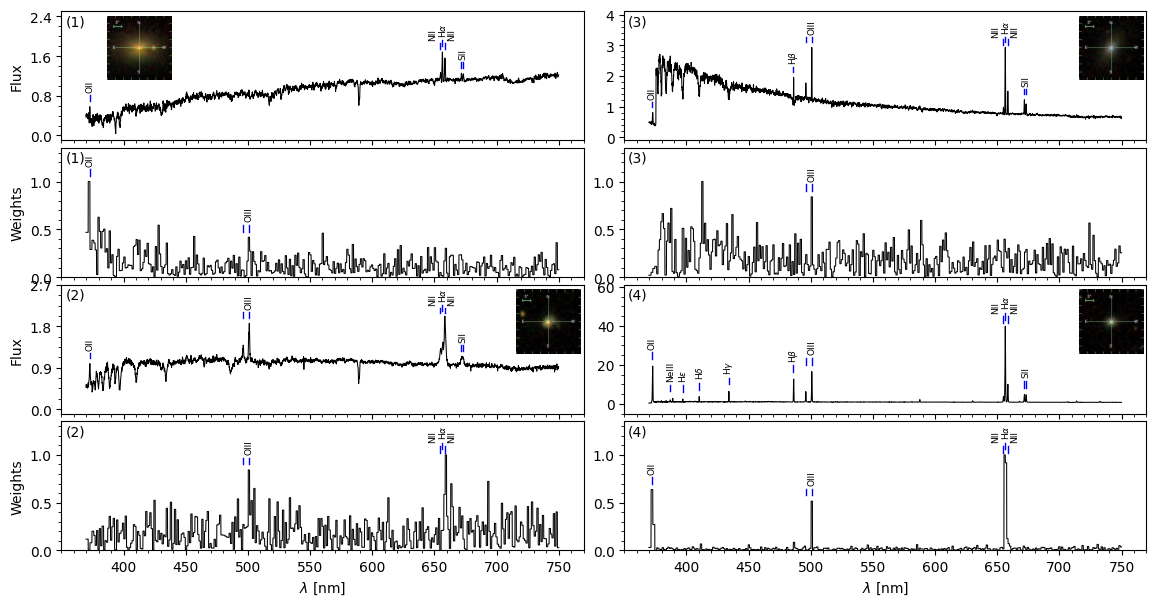

In [27]:
fig, axs = plt.subplots(4, 2, sharex=True, figsize=(14, 7))
line_width_spec = 0.75
line_width_xai = 0.75
# -------------------------------------------------------------------------------------
# 1. Panel Layout Configuration (Dictionary)
# Added text_x and text_y for independent positioning per panel
# -------------------------------------------------------------------------------------
panels = {
    "evolved_H_alpha": {
        "prefix": "(1)",
        "r": 0,
        "c": 0,
        "ylim": (-0.1, 2.5),
        "yticks": [0, 0.8, 1.6, 2.4],
        "bbox_to_anchor": (-0.088, 0.52, 0.5, 0.5),
        "text_x": 0.0075,
        "text_y": 0.925,
        "ha": "left",
        "va": "center",
    },
    "evolved_sf": {
        "prefix": "(2)",
        "r": 2,
        "c": 0,
        "ylim": (-0.1, 2.5),
        "yticks": [0, 0.9, 1.8, 2.7],
        "bbox_to_anchor": (0.695, 0.52, 0.5, 0.5),
        "text_x": 0.0075,
        "text_y": 0.925,
        "ha": "left",
        "va": "center",
    },
    "weird_blue_excess": {
        "prefix": "(3)",
        "r": 0,
        "c": 1,
        "ylim": (-0.1, 4.1),
        "yticks": range(0, 5, 1),
        "bbox_to_anchor": (0.695, 0.52, 0.5, 0.5),
        "text_x": 0.0075,
        "text_y": 0.925,
        "ha": "left",
        "va": "center",
    },
    "emission_line": {
        "prefix": "(4)",
        "r": 2,
        "c": 1,
        "ylim": (-5, 61),
        "yticks": range(0, 65, 20),
        "bbox_to_anchor": (0.695, 0.52, 0.5, 0.5),
        "text_x": 0.0075,
        "text_y": 0.925,
        "ha": "left",
        "va": "center",
    },
}
# -------------------------------------------------------------------------------------
# 2. Line Indicator Configuration
# -------------------------------------------------------------------------------------
line_configs = {
    "evolved_H_alpha": {
        "top": {
            "indicator_starts": 0.12,
            "indicator_height": 0.12,
            "delta": 1,
            "fontsize": 6.5,
            "active_lines": ["OII", "H_alpha", "SII"],
        },
        "bot": {
            "indicator_starts": 0.06,
            "indicator_height": 0.07,
            "delta": 6,
            "fontsize": 6.5,
            "active_lines": ["OII", "OIII"],
        },
    },
    "evolved_sf": {
        "top": {
            "indicator_starts": 0.12,
            "indicator_height": 0.12,
            "delta": 10,
            "fontsize": 6.5,
            "active_lines": ["OII", "OIII", "H_alpha", "SII"],
        },
        "bot": {
            "indicator_starts": 0.06,
            "indicator_height": 0.07,
            "delta": 6,
            "fontsize": 6.5,
            "active_lines": ["OIII", "H_alpha"],
        },
    },
    "weird_blue_excess": {
        "top": {
            "indicator_starts": 0.175,
            "indicator_height": 0.175,
            "delta": 2,
            "fontsize": 6.5,
            "active_lines": ["OII", "H_beta", "OIII", "H_alpha", "SII"],
        },
        "bot": {
            "indicator_starts": 0.06,
            "indicator_height": 0.07,
            "delta": 2,
            "fontsize": 6.5,
            "active_lines": ["OIII"],
        },
    },
    "emission_line": {
        "top": {
            "indicator_starts": 3.5,
            "indicator_height": 3.5,
            "delta": 5,
            "fontsize": 6.5,
            "active_lines": [
                "OII",
                "NeIII",
                "H_epsilon",
                "H_delta",
                "H_gamma",
                "H_beta",
                "OIII",
                "H_alpha",
                "SII",
            ],
        },
        "bot": {
            "indicator_starts": 0.06,
            "indicator_height": 0.07,
            "delta": 2,
            "fontsize": 6.5,
            "active_lines": ["OII", "OIII", "H_alpha"],
        },
    },
}
# -------------------------------------------------------------------------------------
# 3. Main Plotting Loop
# -------------------------------------------------------------------------------------
for name, p_conf in panels.items():

    # Panel variables
    prefix, r, c = p_conf["prefix"], p_conf["r"], p_conf["c"]
    ylim, yticks = p_conf["ylim"], p_conf["yticks"]
    bbox_to_anchor = p_conf["bbox_to_anchor"]
    text_x, text_y = p_conf["text_x"], p_conf["text_y"]
    ha, va = p_conf["ha"], p_conf["va"]

    # Line configs for panel (default to empty dicts if none exist)
    configs = line_configs.get(name, {})
    top_lines = configs.get("top", {})
    bot_lines = configs.get("bot", {})

    # --- Top Plot: Spec + Thumbnail ---
    axs[r, c], _ = spec_photo_thumbnail(
        axs[r, c],
        wave_nm,
        spec_lof_dict[name],
        img_lof_dict[name],
        add_image=True,
        bbox_to_anchor=bbox_to_anchor,
        lw=line_width_spec,
    )
    axs[r, c].set_ylim(ylim)
    axs[r, c].set_yticks(yticks)
    axs[r, c].minorticks_on()
    axs[r, c].text(
        text_x,
        text_y,
        f"{prefix}",
        ha=ha,
        va=va,
        transform=axs[r, c].transAxes,
    )

    if c == 0:
        axs[r, c].set_ylabel("Flux")

    # Add line indicators
    if top_lines.get("active_lines"):
        add_line_indicators(axs[r, c], wave_nm, spec_lof_dict[name], **top_lines)

    # --- Bottom Plot: Explanation Weights ---
    axs[r + 1, c], _ = spec_photo_thumbnail(
        axs[r + 1, c], wave_nm, xai_lof_dict[name], lw=line_width_xai
    )
    axs[r + 1, c].set_ylim(0, 1.35)
    axs[r + 1, c].set_yticks([0, 0.5, 1])
    axs[r + 1, c].minorticks_on()
    axs[r + 1, c].text(
        text_x,
        text_y,
        f"{prefix}",
        ha=ha,
        va=va,
        transform=axs[r + 1, c].transAxes,
    )

    if c == 0:
        axs[r + 1, c].set_ylabel("Weights")

    # Add line indicators
    if bot_lines.get("active_lines"):
        add_line_indicators(axs[r + 1, c], wave_nm, xai_lof_dict[name], **bot_lines)
# -------------------------------------------------------------------------------------
# 4. Global Axes Settings (Bottom Row)
# -------------------------------------------------------------------------------------
wave_ticks = list(np.arange(400, 751, 50))
for col in [0, 1]:
    axs[3, col].set_xlim(350, 770)
    axs[3, col].set_xticks(wave_ticks)
    axs[3, col].set_xlabel(r"$\lambda$ [nm]")

plt.subplots_adjust(hspace=0.06, wspace=0.078)
# Save figure
fig.savefig(f"{ch_5_dir}/lof_distinct_xai.pdf", bbox_inches="tight")